# NUS ST5207 — Nonparametric Regression
## Expanded Tutorial + Deep Experiments + Real Case Study + Worked Solutions

This notebook is a more detailed, tutor-style treatment of the main nonparametric regression ideas.

It covers:

1. Parametric vs nonparametric regression
2. Histogram density estimation
3. Kernel Density Estimation (KDE)
4. Kernel choice and bandwidth
5. Nadaraya–Watson regression
6. Local polynomial regression
7. Cross-validation for smoothing parameters
8. Boundary bias
9. Regression splines
10. Penalized / smoothing splines
11. Additive models
12. Semiparametric regression
13. Bias–variance experiments
14. Curse of dimensionality
15. Real-data Auto MPG case study
16. Comparison with ML models
17. Solutions to all exercises
18. Effective degrees of freedom
19. Residual diagnostics
20. Complexity analysis

The core problem is

\[
Y_i = m(X_i)+\varepsilon_i,
\]

where

\[
m(x)=E[Y\mid X=x]
\]

is unknown and is estimated flexibly from data.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import UnivariateSpline

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

np.random.seed(42)

def metrics(y_true, y_pred):
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

print("Environment ready")

Environment ready


# 1. Parametric vs Nonparametric Regression

A parametric model assumes a fixed family such as

\[
m(x)=\beta_0+\beta_1x.
\]

A nonparametric model does not force the unknown function into one fixed finite-dimensional form.

This is useful for:
- thresholds,
- saturation,
- curvature,
- non-monotonicity,
- changing slopes,
- local structure.

The trade-off is that flexibility must be controlled carefully.

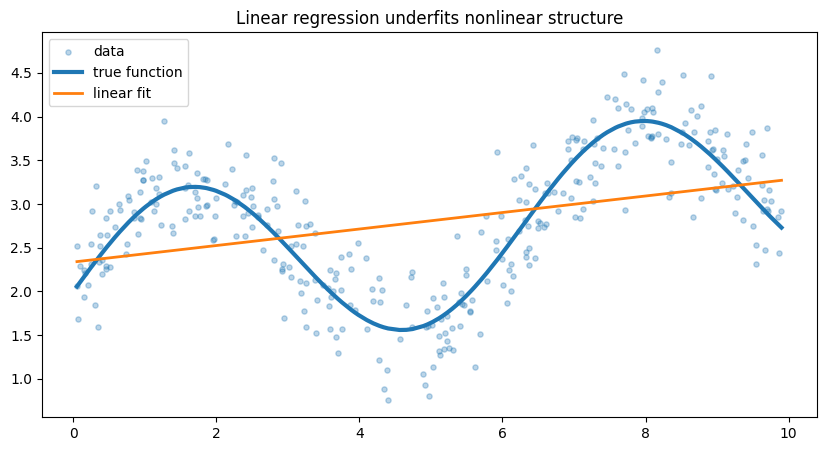

In [2]:
n = 350
x = np.sort(np.random.uniform(0, 10, n))
true_m = 2 + np.sin(x) + 0.12*x
y = true_m + np.random.normal(0, 0.4, n)

X = x.reshape(-1, 1)

linear = LinearRegression().fit(X, y)
grid = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)

plt.figure(figsize=(10,5))
plt.scatter(x, y, s=14, alpha=0.3, label="data")
plt.plot(x, true_m, linewidth=3, label="true function")
plt.plot(x, linear.predict(X), linewidth=2, label="linear fit")
plt.legend()
plt.title("Linear regression underfits nonlinear structure")
plt.show()

## Experiment: Global Polynomial Complexity

Polynomial regression is still parametric:

\[
m(x)=\beta_0+\beta_1x+\cdots+\beta_dx^d.
\]

Increasing degree reduces bias but high-degree global polynomials may oscillate heavily.

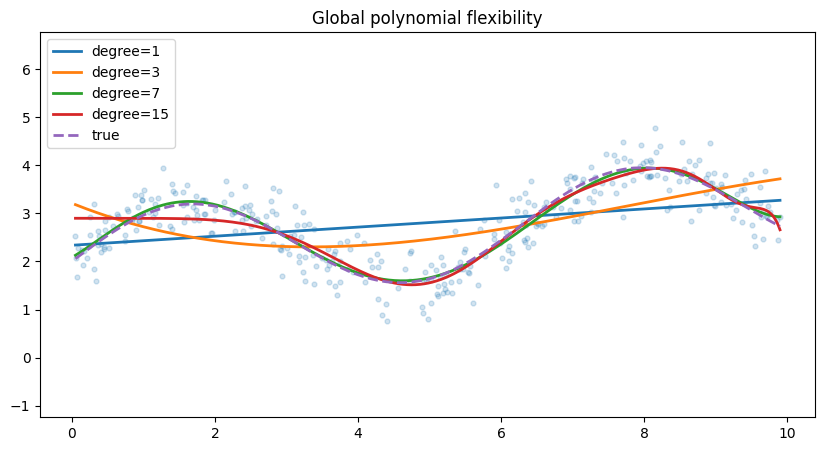

In [3]:
plt.figure(figsize=(10,5))
plt.scatter(x, y, s=12, alpha=0.2)

for degree in [1, 3, 7, 15]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])
    model.fit(X, y)
    plt.plot(grid.ravel(), model.predict(grid), linewidth=2, label=f"degree={degree}")

plt.plot(x, true_m, linestyle="--", linewidth=2, label="true")
plt.ylim(y.min()-2, y.max()+2)
plt.legend()
plt.title("Global polynomial flexibility")
plt.show()

# 2. Histograms and Density Estimation

A histogram estimates an unknown density using piecewise constant bins:

\[
\hat f(x)=\frac{\text{count in bin}}{nh}.
\]

The bin width \(h\) is a smoothing parameter.

Small bins:
- low smoothing,
- high variance.

Large bins:
- high smoothing,
- higher bias.

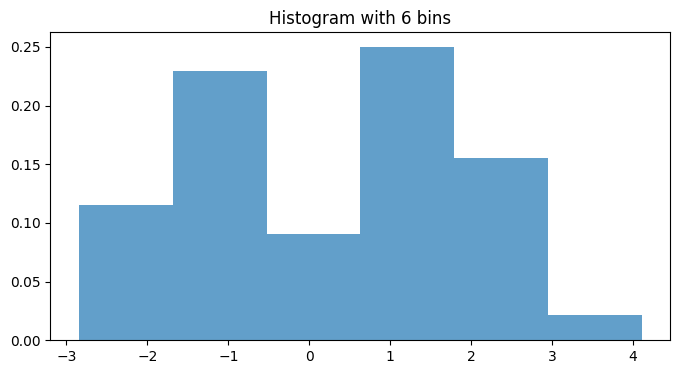

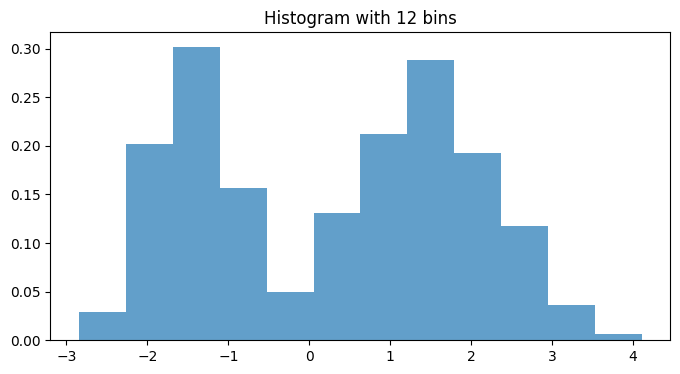

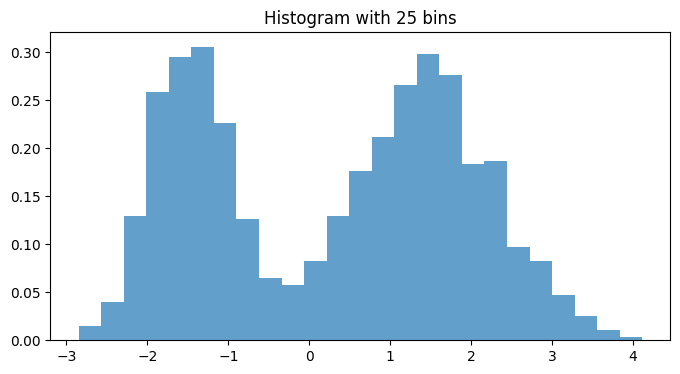

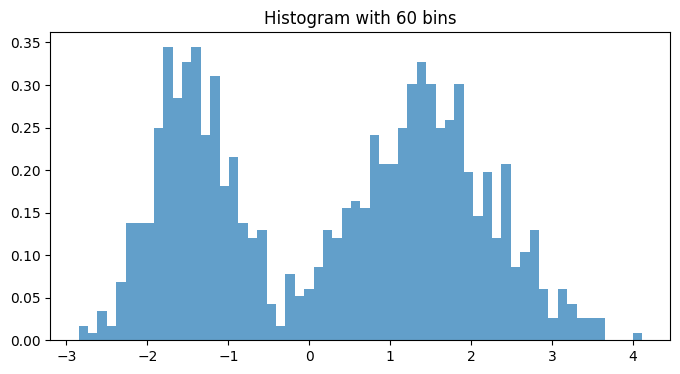

In [4]:
sample = np.concatenate([
    np.random.normal(-1.5, 0.5, 400),
    np.random.normal(1.4, 0.85, 600),
])

for bins in [6, 12, 25, 60]:
    plt.figure(figsize=(8,4))
    plt.hist(sample, bins=bins, density=True, alpha=0.7)
    plt.title(f"Histogram with {bins} bins")
    plt.show()

## Experiment: Histogram Origin Sensitivity

Even with the same bin width, shifting the bin grid can change the visual shape substantially.

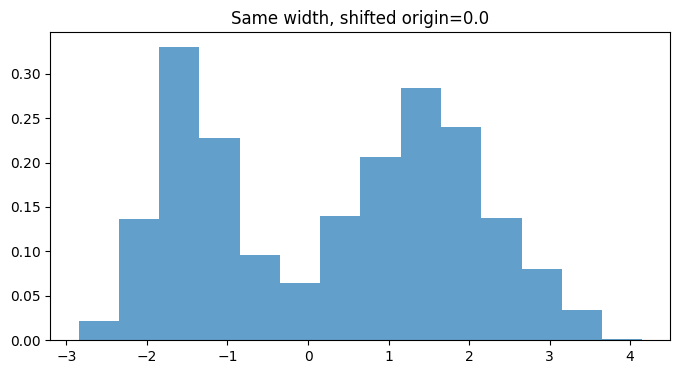

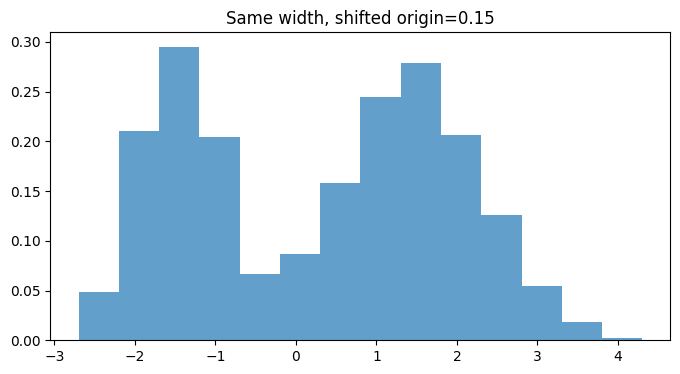

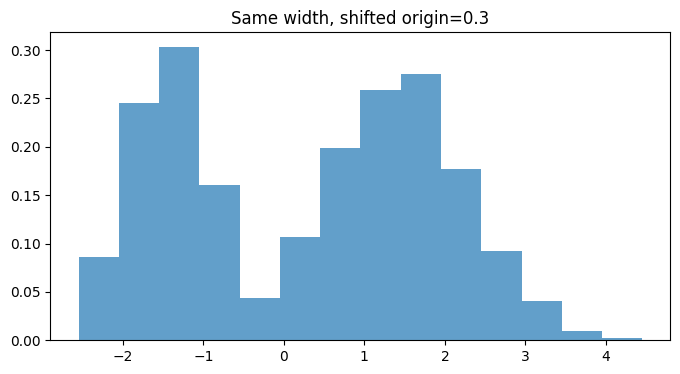

In [5]:
width = 0.5
xmin, xmax = sample.min(), sample.max()

for shift in [0.0, 0.15, 0.30]:
    edges = np.arange(xmin + shift, xmax + width, width)
    plt.figure(figsize=(8,4))
    plt.hist(sample, bins=edges, density=True, alpha=0.7)
    plt.title(f"Same width, shifted origin={shift}")
    plt.show()

# 3. Kernel Density Estimation

KDE smooths the density estimate:

\[
\hat f_h(x)=
\frac1{nh}
\sum_{i=1}^n
K\left(\frac{x-X_i}{h}\right).
\]

Interpretation:
1. center a kernel at each observation,
2. scale by bandwidth \(h\),
3. average.

The bandwidth is usually more important than the exact kernel.

In [6]:
def gaussian_kernel(u):
    return np.exp(-0.5*u**2) / np.sqrt(2*np.pi)

def uniform_kernel(u):
    return 0.5 * (np.abs(u) <= 1)

def triangular_kernel(u):
    return np.maximum(1 - np.abs(u), 0)

def epanechnikov_kernel(u):
    return 0.75*(1-u**2)*(np.abs(u) <= 1)

KERNELS = {
    "Gaussian": gaussian_kernel,
    "Uniform": uniform_kernel,
    "Triangular": triangular_kernel,
    "Epanechnikov": epanechnikov_kernel
}

def kde_1d(x_eval, x_train, bandwidth, kernel=gaussian_kernel):
    x_eval = np.asarray(x_eval)[:, None]
    x_train = np.asarray(x_train)[None, :]
    u = (x_eval - x_train) / bandwidth
    return kernel(u).mean(axis=1) / bandwidth

density_grid = np.linspace(sample.min()-1, sample.max()+1, 500)

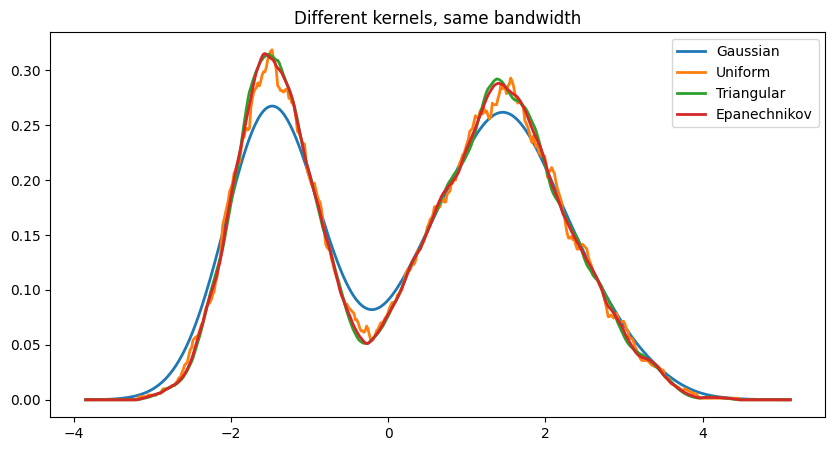

In [7]:
plt.figure(figsize=(10,5))
for name, kernel in KERNELS.items():
    plt.plot(
        density_grid,
        kde_1d(density_grid, sample, 0.35, kernel),
        linewidth=2,
        label=name
    )
plt.legend()
plt.title("Different kernels, same bandwidth")
plt.show()

## Experiment: Bandwidth Sensitivity

For smooth densities,

\[
\mathrm{MSE}(h)\approx C_1h^4+\frac{C_2}{nh}.
\]

Balancing the two terms yields the canonical one-dimensional rate

\[
h_{\text{opt}}=O(n^{-1/5}).
\]

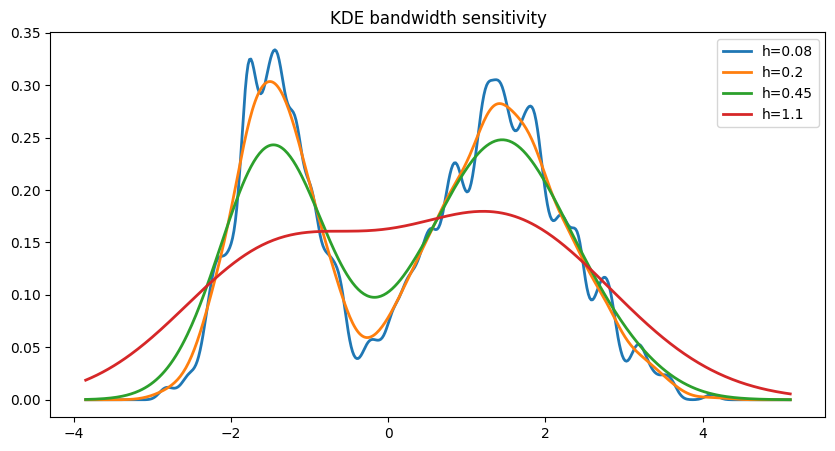

In [8]:
plt.figure(figsize=(10,5))
for h in [0.08, 0.20, 0.45, 1.10]:
    plt.plot(
        density_grid,
        kde_1d(density_grid, sample, h),
        linewidth=2,
        label=f"h={h}"
    )
plt.legend()
plt.title("KDE bandwidth sensitivity")
plt.show()

# 4. Nadaraya–Watson Kernel Regression

The estimator is

\[
\hat m_h(x)=
\frac{
\sum_i K\left(\frac{x-X_i}{h}\right)Y_i
}{
\sum_i K\left(\frac{x-X_i}{h}\right)
}.
\]

It is a locally weighted average of responses.

In [9]:
class NadarayaWatsonRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, bandwidth=1.0, kernel="gaussian"):
        self.bandwidth = bandwidth
        self.kernel = kernel

    def _kernel(self):
        return {
            "gaussian": gaussian_kernel,
            "uniform": uniform_kernel,
            "triangular": triangular_kernel,
            "epanechnikov": epanechnikov_kernel
        }[self.kernel]

    def fit(self, X, y):
        self.X_ = np.asarray(X).reshape(-1)
        self.y_ = np.asarray(y)
        return self

    def predict(self, X):
        X = np.asarray(X).reshape(-1)
        k = self._kernel()
        out = []

        for x0 in X:
            w = k((x0 - self.X_) / self.bandwidth)
            out.append(
                self.y_.mean() if w.sum() < 1e-12
                else np.dot(w, self.y_) / w.sum()
            )

        return np.asarray(out)

## Experiment: What the Bandwidth Actually Does

At a fixed query point \(x_0\), the bandwidth changes the spatial spread of influence.

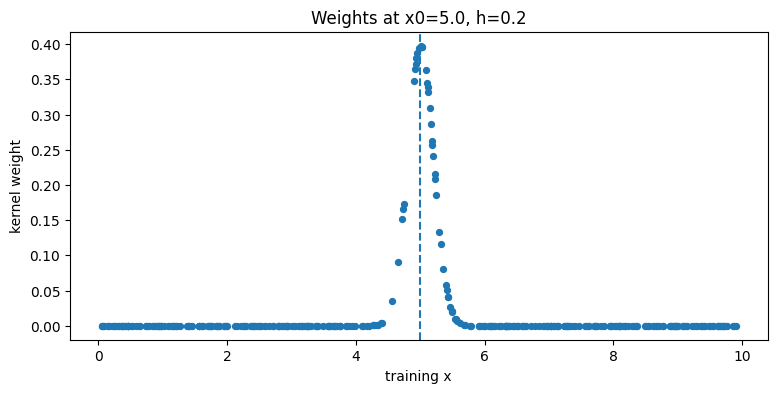

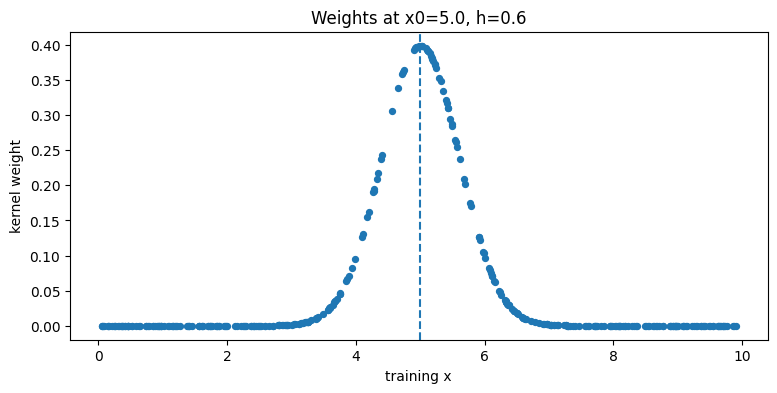

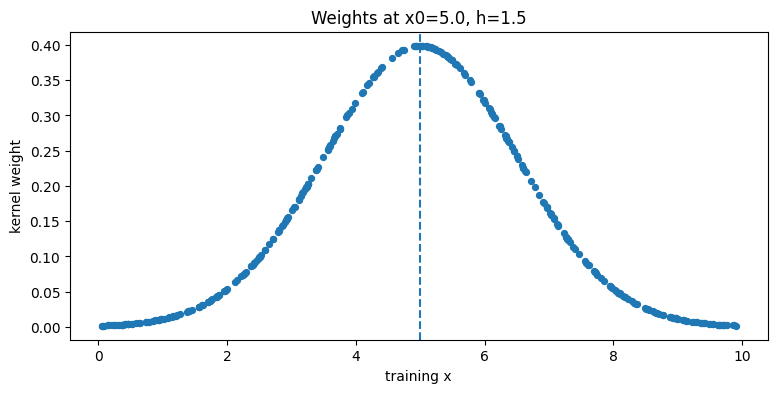

In [10]:
x0 = 5.0

for h in [0.2, 0.6, 1.5]:
    w = gaussian_kernel((x0 - x)/h)

    plt.figure(figsize=(9,4))
    plt.scatter(x, w, s=18)
    plt.axvline(x0, linestyle="--")
    plt.xlabel("training x")
    plt.ylabel("kernel weight")
    plt.title(f"Weights at x0={x0}, h={h}")
    plt.show()

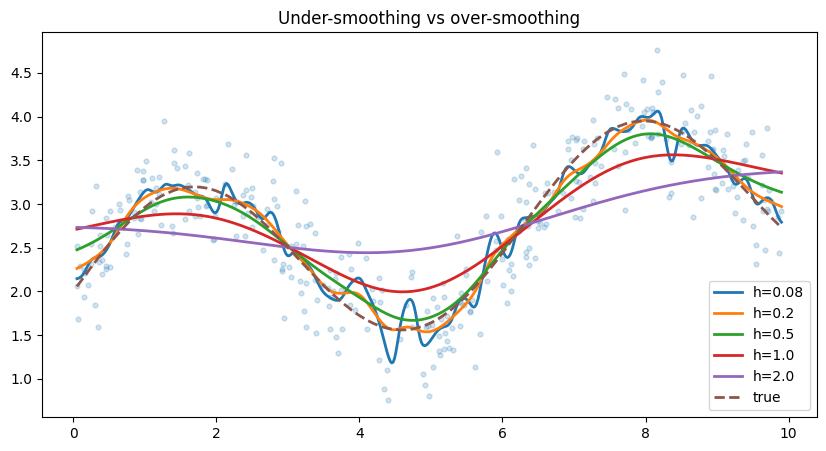

In [11]:
grid_r = grid.ravel()

plt.figure(figsize=(10,5))
plt.scatter(x, y, s=12, alpha=0.2)

for h in [0.08, 0.2, 0.5, 1.0, 2.0]:
    model = NadarayaWatsonRegressor(h).fit(x, y)
    plt.plot(grid_r, model.predict(grid_r), linewidth=2, label=f"h={h}")

plt.plot(x, true_m, linestyle="--", linewidth=2, label="true")
plt.legend()
plt.title("Under-smoothing vs over-smoothing")
plt.show()

# 5. Cross-Validation for Bandwidth

Leave-one-out cross-validation uses

\[
CV(h)=
\frac1n
\sum_i
\left[Y_i-\hat m_{-i,h}(X_i)\right]^2.
\]

Each point is predicted without using itself.

Best bandwidth: 0.24


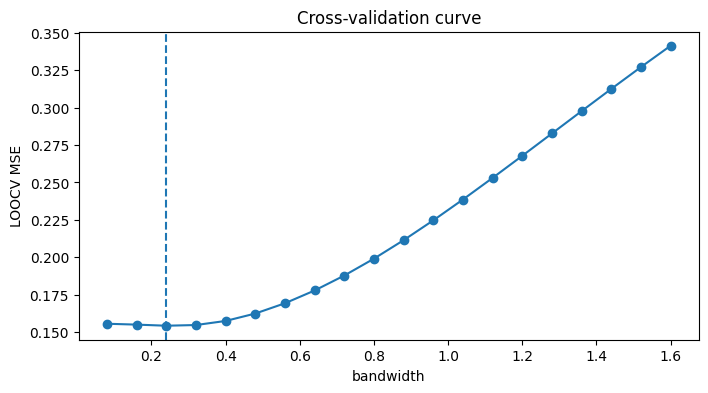

In [12]:
def loo_cv_nw(x, y, bandwidth, kernel="gaussian"):
    x = np.asarray(x)
    y = np.asarray(y)
    errors = []

    for i in range(len(x)):
        mask = np.arange(len(x)) != i
        model = NadarayaWatsonRegressor(bandwidth, kernel).fit(x[mask], y[mask])
        pred = model.predict([x[i]])[0]
        errors.append((y[i]-pred)**2)

    return np.mean(errors)

candidate_h = np.linspace(0.08, 1.6, 20)
scores = [loo_cv_nw(x, y, h) for h in candidate_h]
best_h = candidate_h[np.argmin(scores)]

print("Best bandwidth:", best_h)

plt.figure(figsize=(8,4))
plt.plot(candidate_h, scores, marker="o")
plt.axvline(best_h, linestyle="--")
plt.xlabel("bandwidth")
plt.ylabel("LOOCV MSE")
plt.title("Cross-validation curve")
plt.show()

# 6. Local Polynomial Regression

Local linear regression approximates near \(x_0\):

\[
m(x)\approx \beta_0+\beta_1(x-x_0).
\]

It solves a weighted least-squares problem at each query point.

Local degree 0 = local constant.

Local degree 1 = local linear.

Local degree 2 = local quadratic.

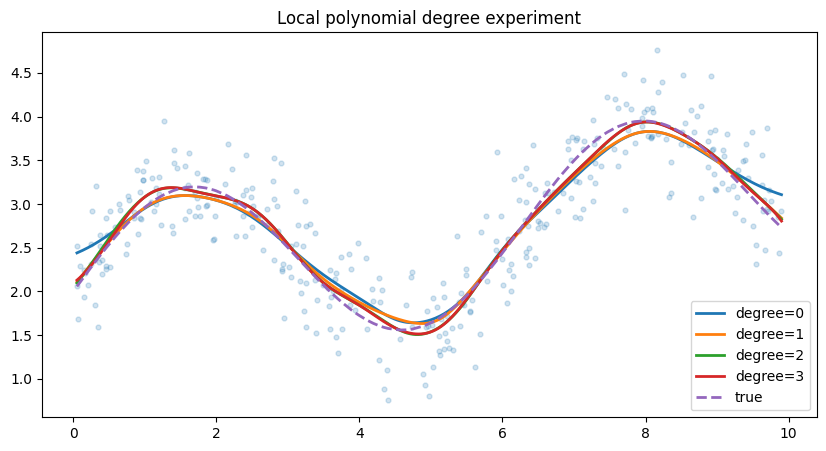

In [13]:
def local_polynomial_predict(
    x_train, y_train, x_eval,
    bandwidth, degree=1,
    kernel=gaussian_kernel
):
    x_train = np.asarray(x_train)
    y_train = np.asarray(y_train)
    x_eval = np.asarray(x_eval)
    preds = []

    for x0 in x_eval:
        dx = x_train - x0
        w = kernel(dx / bandwidth)

        A = np.column_stack([
            dx**j for j in range(degree+1)
        ])

        sw = np.sqrt(w)
        Aw = A * sw[:, None]
        yw = y_train * sw

        beta, *_ = np.linalg.lstsq(Aw, yw, rcond=None)
        preds.append(beta[0])

    return np.asarray(preds)

plt.figure(figsize=(10,5))
plt.scatter(x, y, s=12, alpha=0.2)

for degree in [0,1,2,3]:
    pred = local_polynomial_predict(
        x, y, grid_r,
        bandwidth=0.45,
        degree=degree
    )
    plt.plot(grid_r, pred, linewidth=2, label=f"degree={degree}")

plt.plot(x, true_m, linestyle="--", linewidth=2, label="true")
plt.legend()
plt.title("Local polynomial degree experiment")
plt.show()

# 7. Boundary Bias

Kernel smoothers behave differently at the edge of the data because the local neighborhood becomes asymmetric.

Local linear regression often reduces this edge bias relative to local constant regression.

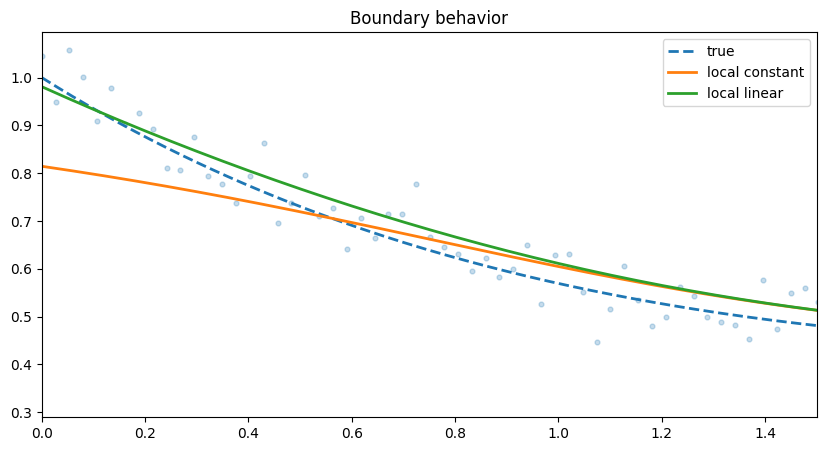

In [14]:
xb = np.linspace(0,4,150)
yb_true = np.exp(-0.8*xb) + 0.12*xb
yb = yb_true + np.random.normal(0,0.05,len(xb))
gb = np.linspace(0,4,400)

p0 = local_polynomial_predict(xb, yb, gb, 0.5, degree=0)
p1 = local_polynomial_predict(xb, yb, gb, 0.5, degree=1)

plt.figure(figsize=(10,5))
plt.scatter(xb, yb, s=12, alpha=0.25)
plt.plot(gb, np.exp(-0.8*gb)+0.12*gb, linestyle="--", linewidth=2, label="true")
plt.plot(gb, p0, linewidth=2, label="local constant")
plt.plot(gb, p1, linewidth=2, label="local linear")
plt.xlim(0,1.5)
plt.legend()
plt.title("Boundary behavior")
plt.show()

# 8. Regression Splines

A regression spline uses basis functions:

\[
m(x)=\sum_{j=1}^{K}\beta_j B_j(x).
\]

Important choices:
- spline degree,
- number of knots,
- knot locations,
- regularization.

Splines are local and usually more stable than high-degree global polynomials.

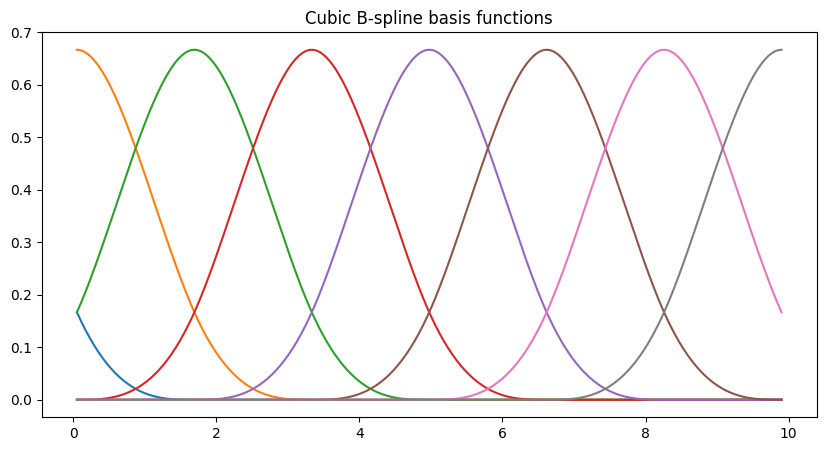

In [15]:
basis = SplineTransformer(
    n_knots=7,
    degree=3,
    include_bias=False
)

B = basis.fit_transform(grid)

plt.figure(figsize=(10,5))
for j in range(B.shape[1]):
    plt.plot(grid_r, B[:,j], linewidth=1.5)
plt.title("Cubic B-spline basis functions")
plt.show()

## Experiment: Knot Count

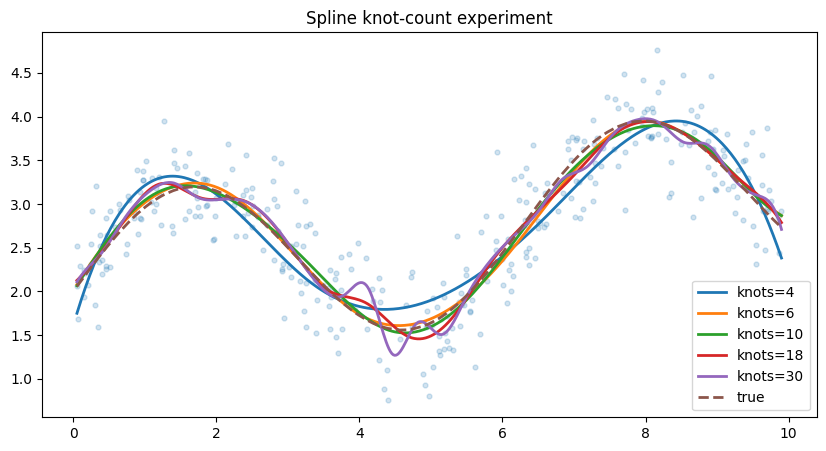

In [16]:
plt.figure(figsize=(10,5))
plt.scatter(x, y, s=12, alpha=0.2)

for knots in [4,6,10,18,30]:
    model = Pipeline([
        ("spline", SplineTransformer(
            n_knots=knots,
            degree=3,
            include_bias=False
        )),
        ("linear", LinearRegression())
    ])
    model.fit(X,y)
    plt.plot(grid_r, model.predict(grid), linewidth=2, label=f"knots={knots}")

plt.plot(x, true_m, linestyle="--", linewidth=2, label="true")
plt.legend()
plt.title("Spline knot-count experiment")
plt.show()

# 9. Penalized Splines

A rich spline basis can be regularized with Ridge:

\[
\hat\beta=
\arg\min_\beta
\left[
\|y-B\beta\|_2^2
+
\alpha\|\beta\|_2^2
\right].
\]

Larger \(\alpha\) reduces effective model flexibility.

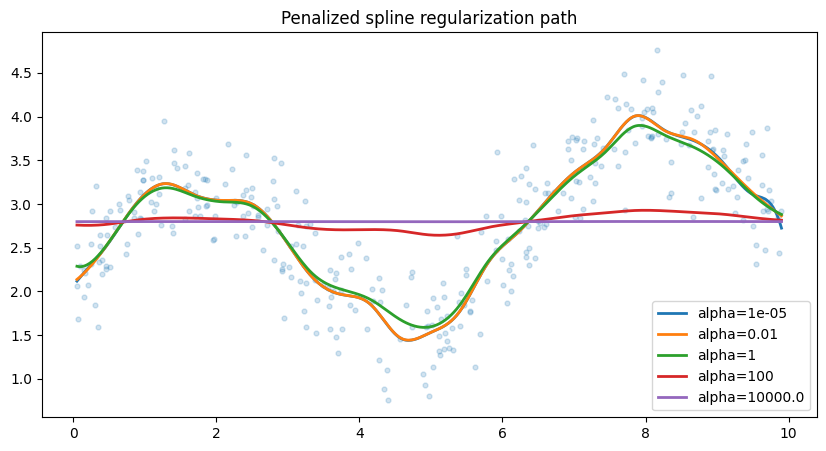

In [17]:
plt.figure(figsize=(10,5))
plt.scatter(x, y, s=12, alpha=0.2)

for alpha in [1e-5,1e-2,1,100,1e4]:
    model = Pipeline([
        ("spline", SplineTransformer(
            n_knots=25,
            degree=3,
            include_bias=False
        )),
        ("ridge", Ridge(alpha=alpha))
    ])
    model.fit(X,y)
    plt.plot(grid_r, model.predict(grid), linewidth=2, label=f"alpha={alpha}")

plt.legend()
plt.title("Penalized spline regularization path")
plt.show()

# 10. Classical Smoothing Splines

A classical smoothing spline minimizes

\[
\sum_i(Y_i-f(X_i))^2
+
\lambda\int[f''(x)]^2dx.
\]

The curvature penalty discourages unnecessary wiggles.

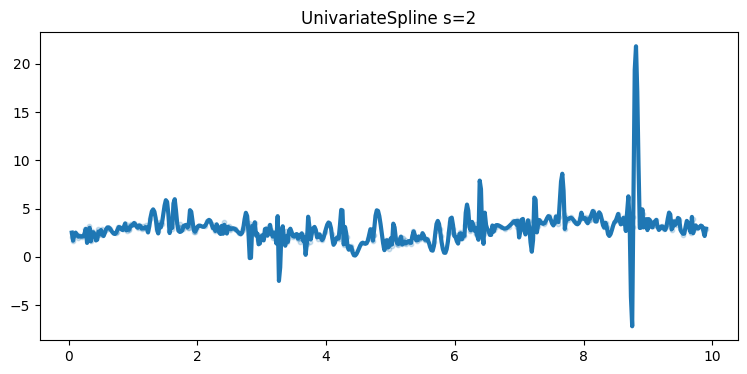

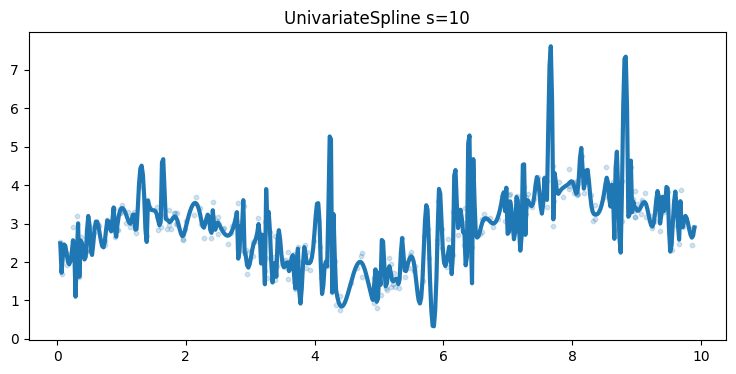

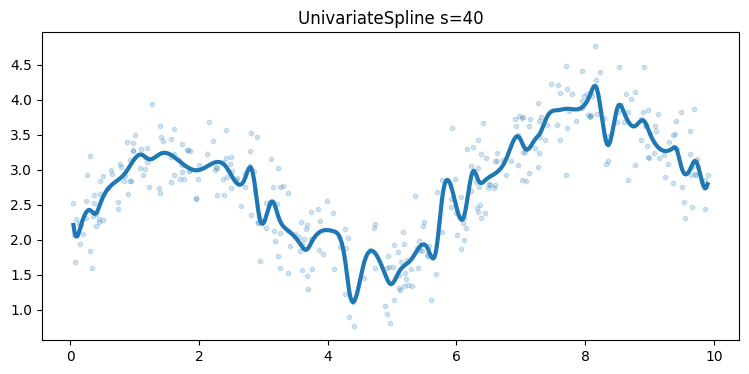

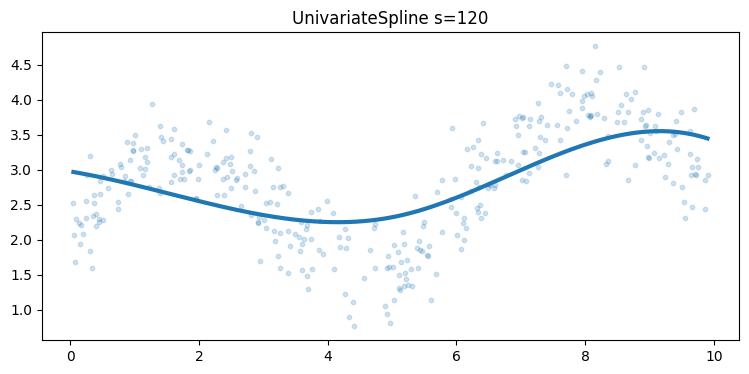

In [18]:
for s in [2,10,40,120]:
    spl = UnivariateSpline(x,y,s=s)

    plt.figure(figsize=(9,4))
    plt.scatter(x,y,s=10,alpha=0.2)
    plt.plot(grid_r,spl(grid_r),linewidth=3)
    plt.title(f"UnivariateSpline s={s}")
    plt.show()

# 11. Additive Models

A multivariable additive model is

\[
Y=
\beta_0+
f_1(X_1)+
f_2(X_2)+
\cdots+
f_p(X_p)+
\varepsilon.
\]

This allows nonlinear effects while avoiding one unrestricted high-dimensional surface.

In [19]:
n_add = 900
x1 = np.random.uniform(-3,3,n_add)
x2 = np.random.uniform(0,5,n_add)
x3 = np.random.normal(0,1,n_add)

y_add = (
    1.6*np.sin(x1)
    + 0.25*(x2-2.5)**2
    - 0.8*np.tanh(x3)
    + np.random.normal(0,0.35,n_add)
)

def fit_basis(v, n_knots=8):
    tr = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)
    B = tr.fit_transform(np.asarray(v).reshape(-1,1))
    return tr, B

tr1,B1 = fit_basis(x1)
tr2,B2 = fit_basis(x2)
tr3,B3 = fit_basis(x3)

B_add = np.column_stack([B1,B2,B3])
add_model = Ridge(alpha=1.0).fit(B_add,y_add)

print(metrics(y_add,add_model.predict(B_add)))

{'RMSE': 0.34540556138873557, 'MAE': 0.2739759547945814, 'R2': 0.9396825043734316}


## Experiment: Recover Partial Effects

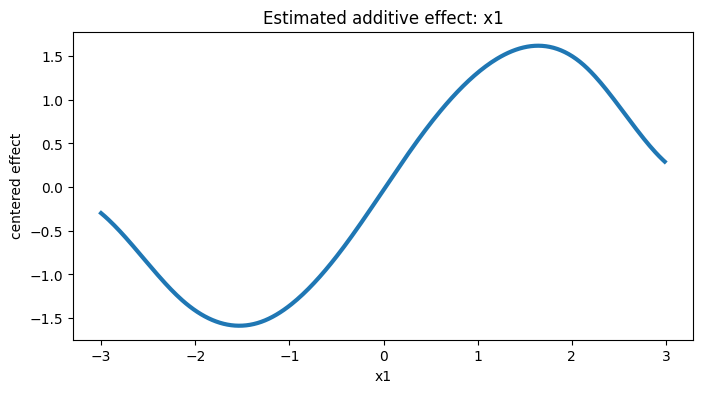

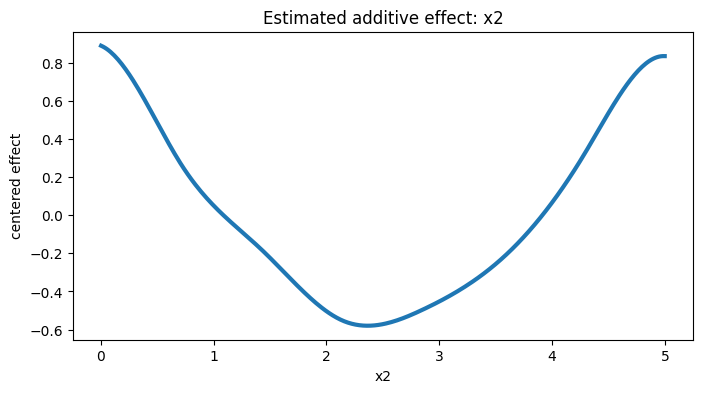

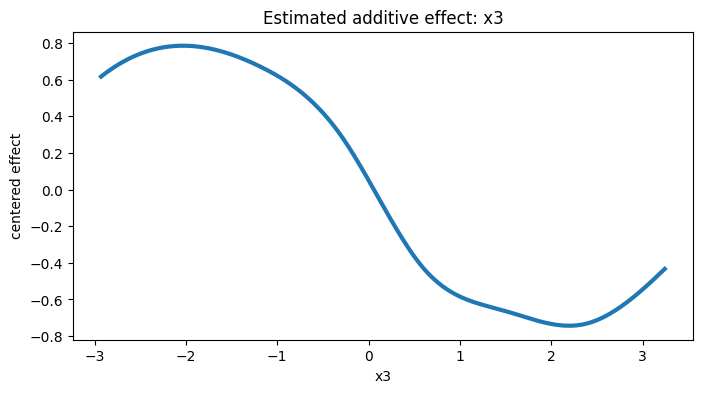

In [20]:
sizes = [B1.shape[1],B2.shape[1],B3.shape[1]]
starts = np.cumsum([0]+sizes[:-1])

for name,values,tr,start,size in [
    ("x1",x1,tr1,starts[0],sizes[0]),
    ("x2",x2,tr2,starts[1],sizes[1]),
    ("x3",x3,tr3,starts[2],sizes[2])
]:
    g = np.linspace(values.min(),values.max(),300)
    Bg = tr.transform(g.reshape(-1,1))
    coef = add_model.coef_[start:start+size]
    effect = Bg@coef
    effect -= effect.mean()

    plt.figure(figsize=(8,4))
    plt.plot(g,effect,linewidth=3)
    plt.xlabel(name)
    plt.ylabel("centered effect")
    plt.title(f"Estimated additive effect: {name}")
    plt.show()

# 12. Semiparametric Regression

A partially linear model combines parametric and nonparametric parts:

\[
Y=Z^\top\beta+g(X)+\varepsilon.
\]

This is useful when some coefficients need direct interpretation while other effects are allowed to be nonlinear.

In [21]:
n_semi = 800
xs = np.random.uniform(0,8,n_semi)
zs = np.random.normal(size=n_semi)

beta_true = 2.5
g_true = 1.8*np.sin(xs/1.4)

ys = beta_true*zs + g_true + np.random.normal(0,0.45,n_semi)

trs = SplineTransformer(n_knots=10,degree=3,include_bias=False)
Bs = trs.fit_transform(xs.reshape(-1,1))
design = np.column_stack([zs,Bs])

semi = Ridge(alpha=0.05).fit(design,ys)

print("True beta:",beta_true)
print("Estimated beta:",semi.coef_[0])

True beta: 2.5
Estimated beta: 2.4923394593676256


# 13. Bias–Variance Experiment

For a fixed \(x_0\),

\[
\mathrm{MSE}
=
\mathrm{Bias}^2+\mathrm{Variance}+\sigma^2.
\]

Small bandwidths tend to lower bias and increase variance.

Large bandwidths tend to reduce variance but increase smoothing bias.

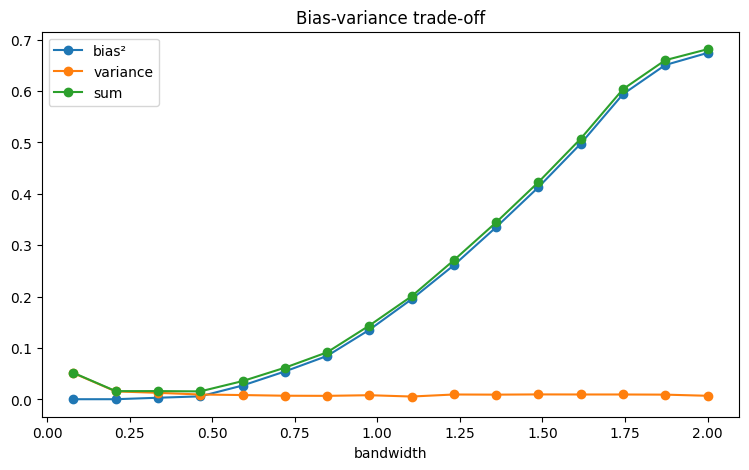

In [22]:
def true_fun(z):
    return 2 + np.sin(z) + 0.12*z

def bv_at_point(h, x0=5.0, reps=120, n_sample=120):
    estimates = []

    for _ in range(reps):
        xx = np.sort(np.random.uniform(0,10,n_sample))
        yy = true_fun(xx) + np.random.normal(0,0.4,n_sample)

        m = NadarayaWatsonRegressor(h).fit(xx,yy)
        estimates.append(m.predict([x0])[0])

    estimates = np.asarray(estimates)

    bias2 = (estimates.mean()-true_fun(x0))**2
    variance = estimates.var()
    return bias2,variance

hs = np.linspace(0.08,2.0,16)
bias2s,vars_ = [],[]

for h in hs:
    b,v = bv_at_point(h)
    bias2s.append(b)
    vars_.append(v)

plt.figure(figsize=(9,5))
plt.plot(hs,bias2s,marker="o",label="bias²")
plt.plot(hs,vars_,marker="o",label="variance")
plt.plot(hs,np.array(bias2s)+np.array(vars_),marker="o",label="sum")
plt.legend()
plt.xlabel("bandwidth")
plt.title("Bias-variance trade-off")
plt.show()

# 14. Curse of Dimensionality

A local hypercube with side width \(r\) in \(d\) dimensions has volume

\[
r^d.
\]

A common nonparametric convergence rate is

\[
n^{-4/(4+d)}.
\]

As \(d\) grows, the exponent shrinks and convergence becomes much slower.

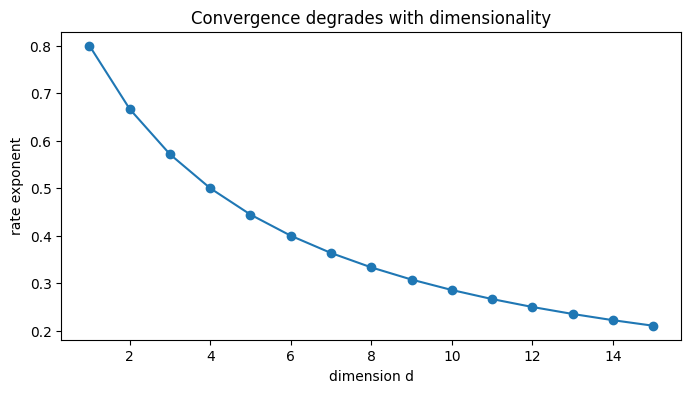

In [23]:
dims = np.arange(1,16)
exponent = 4/(4+dims)

plt.figure(figsize=(8,4))
plt.plot(dims,exponent,marker="o")
plt.xlabel("dimension d")
plt.ylabel("rate exponent")
plt.title("Convergence degrades with dimensionality")
plt.show()

# 15. Real Data Case Study — Auto MPG

The dataset is downloaded directly from the UCI Machine Learning Repository.

Response:

\[
Y=\text{mpg}.
\]

We study nonlinear effects of:
- horsepower,
- weight,
- displacement,
- acceleration,
- model year.

In [24]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = [
    "mpg","cylinders","displacement","horsepower",
    "weight","acceleration","model_year","origin","car_name"
]

auto = pd.read_csv(
    url,
    sep=r"\s+",
    names=columns,
    na_values="?"
).dropna().reset_index(drop=True)

print(auto.shape)
auto.head()

(392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [25]:
auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


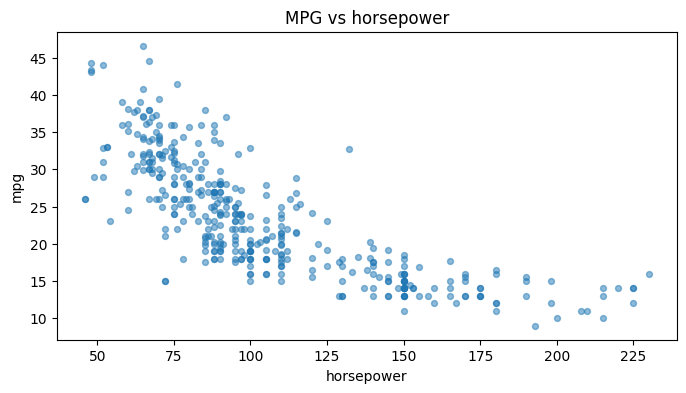

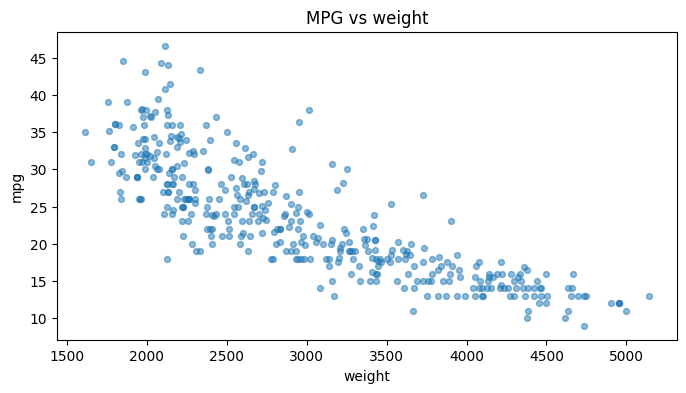

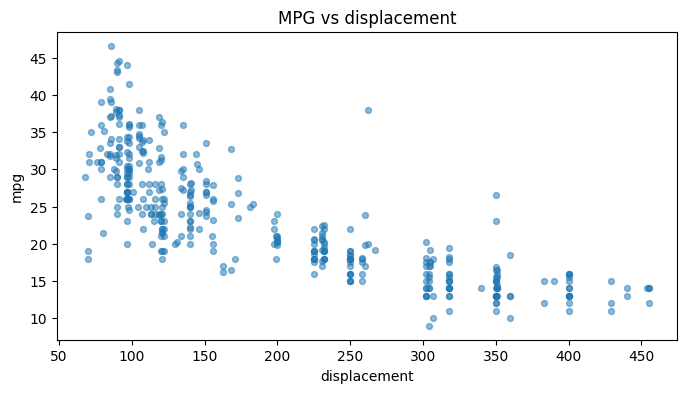

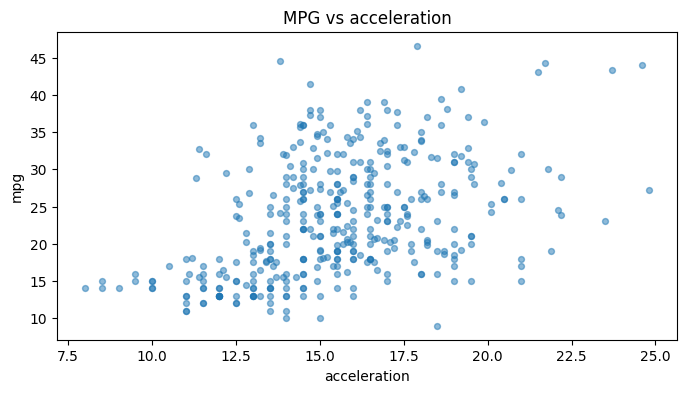

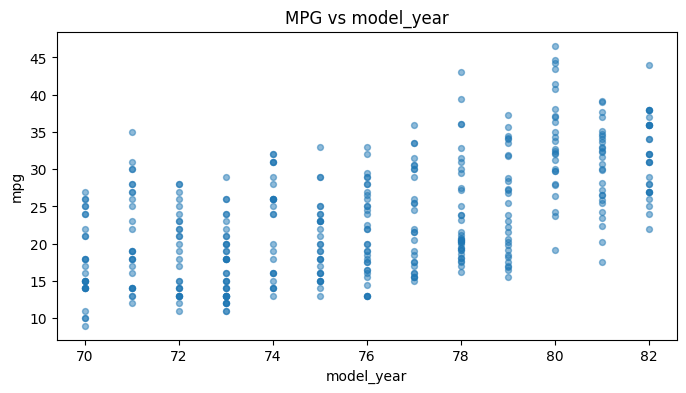

In [26]:
for feature in ["horsepower","weight","displacement","acceleration","model_year"]:
    plt.figure(figsize=(8,4))
    plt.scatter(auto[feature],auto["mpg"],alpha=0.5,s=18)
    plt.xlabel(feature)
    plt.ylabel("mpg")
    plt.title(f"MPG vs {feature}")
    plt.show()

# 16. Horsepower-Only Model Comparison

We compare:
- linear regression,
- Nadaraya–Watson,
- local linear regression,
- regression splines,
- RBF kernel ridge.

In [27]:
X_hp = auto[["horsepower"]].to_numpy()
y_mpg = auto["mpg"].to_numpy()

Xtr,Xte,ytr,yte = train_test_split(
    X_hp,y_mpg,test_size=0.25,random_state=42
)

hp_grid = np.linspace(X_hp.min(),X_hp.max(),500).reshape(-1,1)

linear_hp = LinearRegression().fit(Xtr,ytr)
pred_linear = linear_hp.predict(Xte)
m_linear = metrics(yte,pred_linear)

kf = KFold(n_splits=5,shuffle=True,random_state=42)

In [28]:
# Tune Nadaraya-Watson

rows = []
xtr1 = Xtr.ravel()

for h in np.linspace(4,55,24):
    fold = []

    for ti,vi in kf.split(xtr1):
        model = NadarayaWatsonRegressor(h).fit(xtr1[ti],ytr[ti])
        pred = model.predict(xtr1[vi])
        fold.append(mean_squared_error(ytr[vi],pred)**0.5)

    rows.append((h,np.mean(fold)))

cv_nw = pd.DataFrame(rows,columns=["bandwidth","CV_RMSE"])
best_h_real = cv_nw.loc[cv_nw.CV_RMSE.idxmin(),"bandwidth"]

nw_real = NadarayaWatsonRegressor(best_h_real).fit(xtr1,ytr)
pred_nw = nw_real.predict(Xte.ravel())
m_nw = metrics(yte,pred_nw)

print("Best NW bandwidth:",best_h_real)
m_nw

Best NW bandwidth: 6.217391304347826


{'RMSE': 4.09826226003565, 'MAE': 3.221866096481585, 'R2': 0.666969718813424}

In [29]:
# Tune local linear

rows = []

for h in np.linspace(5,55,16):
    fold = []

    for ti,vi in kf.split(xtr1):
        pred = local_polynomial_predict(
            xtr1[ti],ytr[ti],xtr1[vi],
            bandwidth=h,degree=1
        )
        fold.append(mean_squared_error(ytr[vi],pred)**0.5)

    rows.append((h,np.mean(fold)))

cv_ll = pd.DataFrame(rows,columns=["bandwidth","CV_RMSE"])
best_h_ll = cv_ll.loc[cv_ll.CV_RMSE.idxmin(),"bandwidth"]

pred_ll = local_polynomial_predict(
    xtr1,ytr,Xte.ravel(),
    bandwidth=best_h_ll,degree=1
)

m_ll = metrics(yte,pred_ll)

print("Best local-linear bandwidth:",best_h_ll)
m_ll

Best local-linear bandwidth: 15.0


{'RMSE': 4.116276781430489,
 'MAE': 3.2528145613856374,
 'R2': 0.6640355158121765}

In [30]:
# Tune regression spline

spline_search = GridSearchCV(
    Pipeline([
        ("spline",SplineTransformer(degree=3,include_bias=False)),
        ("ridge",Ridge())
    ]),
    {
        "spline__n_knots":[4,5,6,8,10,12,16],
        "ridge__alpha":[0,0.001,0.01,0.1,1,10,100]
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

spline_search.fit(Xtr,ytr)
pred_spline = spline_search.predict(Xte)
m_spline = metrics(yte,pred_spline)

print(spline_search.best_params_)
m_spline

{'ridge__alpha': 0.1, 'spline__n_knots': 8}


{'RMSE': 4.080686856435488,
 'MAE': 3.2353762927655074,
 'R2': 0.6698199956523616}

In [31]:
# RBF kernel ridge

kr_search = GridSearchCV(
    Pipeline([
        ("scale",StandardScaler()),
        ("kr",KernelRidge(kernel="rbf"))
    ]),
    {
        "kr__alpha":[0.001,0.01,0.1,1,10],
        "kr__gamma":[0.01,0.05,0.1,0.2,0.5,1]
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

kr_search.fit(Xtr,ytr)
pred_kr = kr_search.predict(Xte)
m_kr = metrics(yte,pred_kr)

print(kr_search.best_params_)
m_kr

{'kr__alpha': 0.1, 'kr__gamma': 0.5}


{'RMSE': 4.038986044806033, 'MAE': 3.165415637776419, 'R2': 0.6765337782264624}

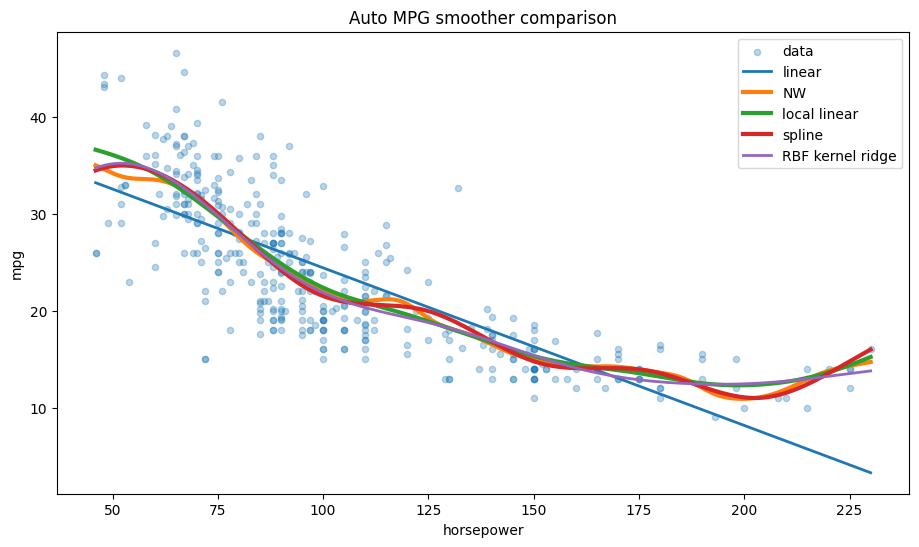

,Model,RMSE,MAE,R2
4,RBF kernel ridge,4.038986,3.165416,0.676534
3,Regression spline,4.080687,3.235376,0.669820
1,Nadaraya-Watson,4.098262,3.221866,0.666970
2,Local linear,4.116277,3.252815,0.664036
0,Linear,4.680724,3.781268,0.565579


In [32]:
plt.figure(figsize=(11,6))
plt.scatter(auto["horsepower"],auto["mpg"],alpha=0.3,s=20,label="data")

plt.plot(hp_grid,linear_hp.predict(hp_grid),linewidth=2,label="linear")
plt.plot(hp_grid,nw_real.predict(hp_grid.ravel()),linewidth=3,label="NW")
plt.plot(
    hp_grid,
    local_polynomial_predict(xtr1,ytr,hp_grid.ravel(),best_h_ll,degree=1),
    linewidth=3,
    label="local linear"
)
plt.plot(hp_grid,spline_search.predict(hp_grid),linewidth=3,label="spline")
plt.plot(hp_grid,kr_search.predict(hp_grid),linewidth=2,label="RBF kernel ridge")

plt.legend()
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.title("Auto MPG smoother comparison")
plt.show()

pd.DataFrame([
    {"Model":"Linear",**m_linear},
    {"Model":"Nadaraya-Watson",**m_nw},
    {"Model":"Local linear",**m_ll},
    {"Model":"Regression spline",**m_spline},
    {"Model":"RBF kernel ridge",**m_kr}
]).sort_values("RMSE")

# 17. Additive Multivariable Auto MPG Model

We fit

\[
\text{mpg}
=
f_1(\text{horsepower})
+
f_2(\text{weight})
+
f_3(\text{displacement})
+
f_4(\text{acceleration})
+
f_5(\text{model year})
+
\varepsilon.
\]

In [33]:
features = ["horsepower","weight","displacement","acceleration","model_year"]

Xm = auto[features].copy()
ym = auto["mpg"].to_numpy()

Xtrm,Xtem,ytrm,ytem = train_test_split(
    Xm,ym,test_size=0.25,random_state=42
)

trs = {}
blocks = []

for col in features:
    tr = SplineTransformer(n_knots=7,degree=3,include_bias=False)
    blocks.append(tr.fit_transform(Xtrm[[col]]))
    trs[col] = tr

Btr = np.column_stack(blocks)
Bte = np.column_stack([trs[col].transform(Xtem[[col]]) for col in features])

best_alpha = None
best_rmse = np.inf

for alpha in np.logspace(-4,4,20):
    fold = []

    for ti,vi in kf.split(Btr):
        m = Ridge(alpha=alpha).fit(Btr[ti],ytrm[ti])
        p = m.predict(Btr[vi])
        fold.append(mean_squared_error(ytrm[vi],p)**0.5)

    avg = np.mean(fold)

    if avg < best_rmse:
        best_rmse = avg
        best_alpha = alpha

additive = Ridge(alpha=best_alpha).fit(Btr,ytrm)
pred_add = additive.predict(Bte)
m_add = metrics(ytem,pred_add)

print("Best alpha:",best_alpha)
m_add

Best alpha: 1.623776739188721


{'RMSE': 2.5152479709489675,
 'MAE': 1.8265280392330485,
 'R2': 0.8745571694119887}

## Inspect Partial Effects

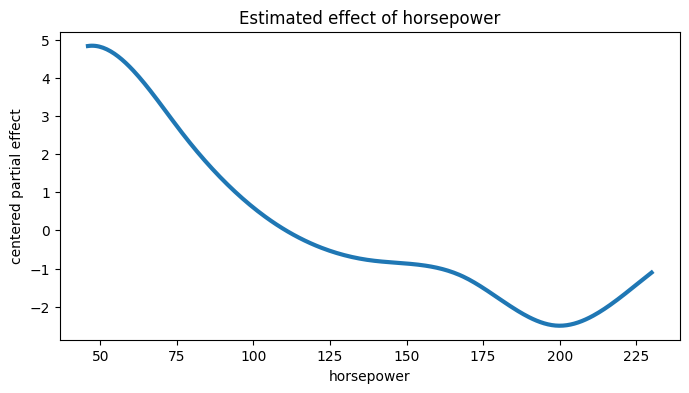

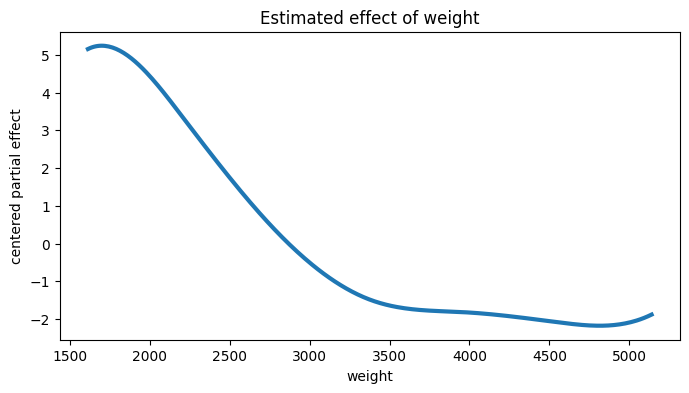

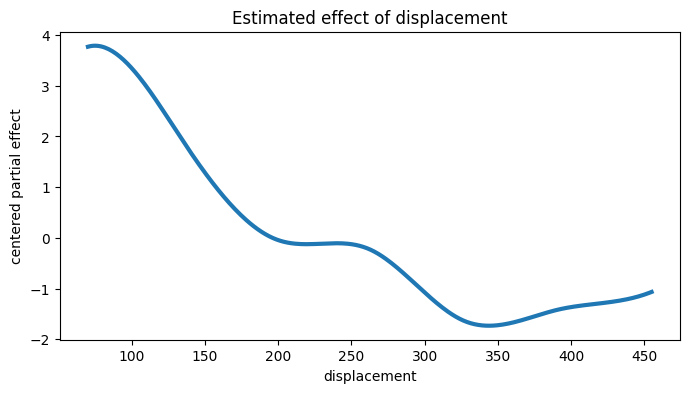

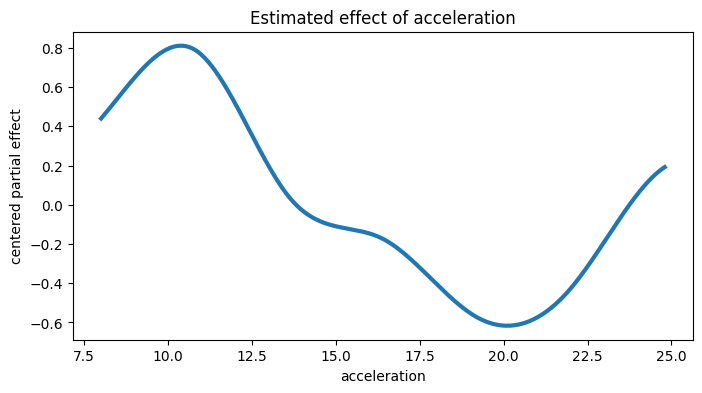

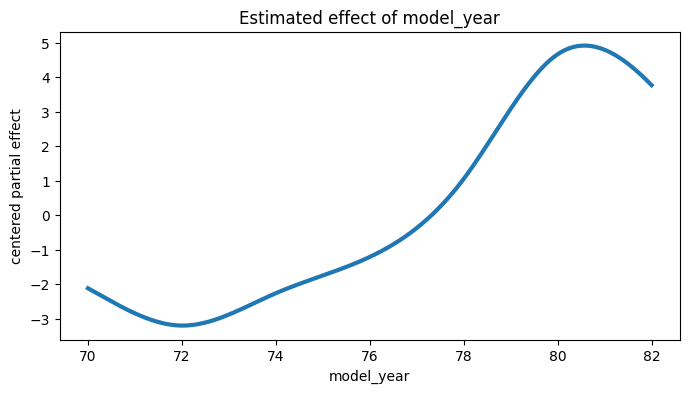

In [34]:
offset = 0

for col in features:
    tr = trs[col]
    k = tr.n_features_out_

    coef = additive.coef_[offset:offset+k]

    g = np.linspace(Xtrm[col].min(),Xtrm[col].max(),300)
    Bg = tr.transform(pd.DataFrame({col:g}))
    effect = Bg@coef
    effect -= effect.mean()

    plt.figure(figsize=(8,4))
    plt.plot(g,effect,linewidth=3)
    plt.xlabel(col)
    plt.ylabel("centered partial effect")
    plt.title(f"Estimated effect of {col}")
    plt.show()

    offset += k

# 18. Semiparametric Auto MPG Model

Suppose:
- horsepower is nonlinear,
- model year is approximately linear.

Then

\[
\text{mpg}
=
\beta_0+
\beta_1(\text{model year})
+
g(\text{horsepower})
+
\varepsilon.
\]

In [35]:
semi_df = auto[["horsepower","model_year","mpg"]]

Xtrs,Xtes,ytrs,ytes = train_test_split(
    semi_df[["horsepower","model_year"]],
    semi_df["mpg"],
    test_size=0.25,
    random_state=42
)

hp_tr = SplineTransformer(n_knots=8,degree=3,include_bias=False)

Bhp_tr = hp_tr.fit_transform(Xtrs[["horsepower"]])
Bhp_te = hp_tr.transform(Xtes[["horsepower"]])

Ztr = np.column_stack([Xtrs["model_year"].to_numpy(),Bhp_tr])
Zte = np.column_stack([Xtes["model_year"].to_numpy(),Bhp_te])

semi_real = Ridge(alpha=0.1).fit(Ztr,ytrs)
pred_semi = semi_real.predict(Zte)

print("Estimated linear model-year coefficient:",semi_real.coef_[0])
metrics(ytes,pred_semi)

Estimated linear model-year coefficient: 0.6915438859666284


{'RMSE': 3.3903303244521332,
 'MAE': 2.672286742872789,
 'R2': 0.7720874402300539}

# 19. Compare with Tree-Based ML

Tree ensembles can be very predictive but do not impose the same smoothness structure as spline/kernel estimators.

This comparison separates:
- prediction,
- interpretability,
- smoothness,
- extrapolation.

In [36]:
all_features = [
    "horsepower","weight","displacement",
    "acceleration","model_year","cylinders","origin"
]

Xf = auto[all_features]
yf = auto["mpg"]

Xtrf,Xtef,ytrf,ytef = train_test_split(
    Xf,yf,test_size=0.25,random_state=42
)

lin_full = LinearRegression().fit(Xtrf,ytrf)

rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
).fit(Xtrf,ytrf)

hgb = HistGradientBoostingRegressor(
    random_state=42
).fit(Xtrf,ytrf)

comparison = pd.DataFrame([
    {"Model":"Linear full",**metrics(ytef,lin_full.predict(Xtef))},
    {"Model":"Random Forest",**metrics(ytef,rf.predict(Xtef))},
    {"Model":"Hist Gradient Boosting",**metrics(ytef,hgb.predict(Xtef))},
    {"Model":"Additive spline",**m_add}
])

comparison.sort_values("RMSE")

,Model,RMSE,MAE,R2
1,Random Forest,2.471832,1.718482,0.878850
3,Additive spline,2.515248,1.826528,0.874557
2,Hist Gradient Boosting,2.561952,1.827195,0.869855
0,Linear full,3.184738,2.408608,0.798891


# 20. Exercise Solutions

## Exercise 1 — KDE Kernel Comparison

Solution: compare Gaussian, Uniform, Triangular, and Epanechnikov kernels at the same bandwidth.

Interpretation: the estimates often differ less than they do when bandwidth changes.

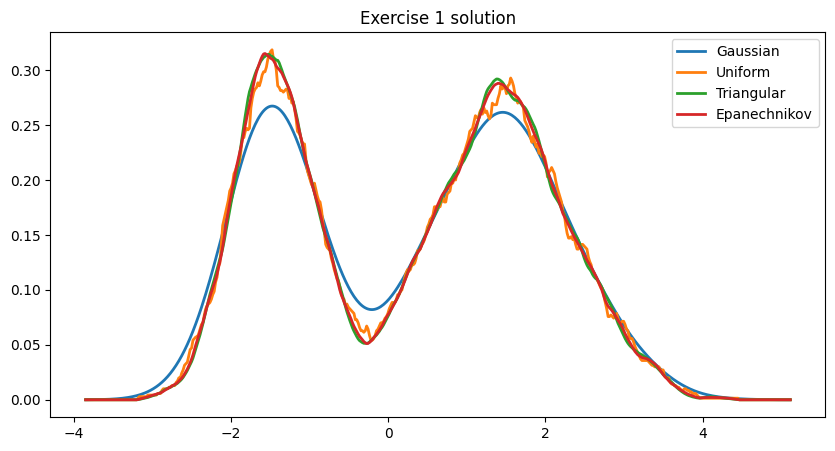

In [37]:
plt.figure(figsize=(10,5))

for name,kernel in KERNELS.items():
    est = kde_1d(density_grid,sample,0.35,kernel)
    plt.plot(density_grid,est,linewidth=2,label=name)

plt.legend()
plt.title("Exercise 1 solution")
plt.show()

## Exercise 2 — Epanechnikov Kernel Regression

The Epanechnikov kernel is

\[
K(u)=\frac34(1-u^2)\mathbf 1(|u|\le1).
\]

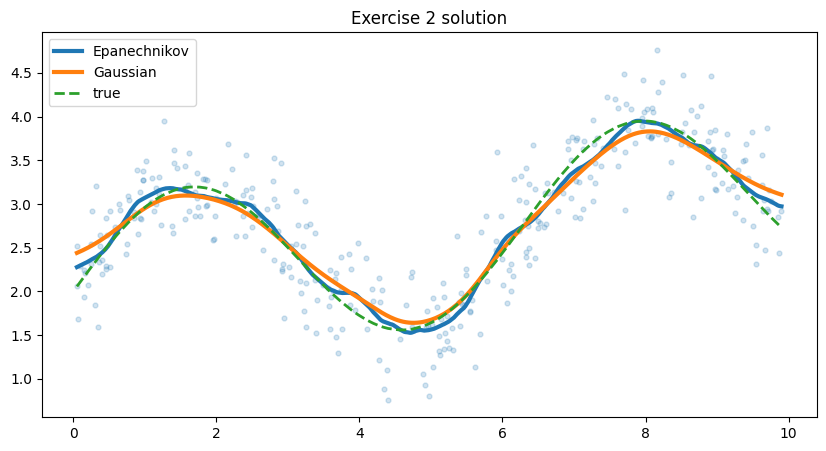

In [38]:
epan = NadarayaWatsonRegressor(
    bandwidth=0.45,
    kernel="epanechnikov"
).fit(x,y)

gauss = NadarayaWatsonRegressor(
    bandwidth=0.45,
    kernel="gaussian"
).fit(x,y)

plt.figure(figsize=(10,5))
plt.scatter(x,y,s=12,alpha=0.2)
plt.plot(grid_r,epan.predict(grid_r),linewidth=3,label="Epanechnikov")
plt.plot(grid_r,gauss.predict(grid_r),linewidth=3,label="Gaussian")
plt.plot(x,true_m,linestyle="--",linewidth=2,label="true")
plt.legend()
plt.title("Exercise 2 solution")
plt.show()

## Exercise 3 — Tune Local Polynomial Degree

We compare degrees \(0,1,2,3\) and tune bandwidth separately for each.

In [39]:
degree_rows = []
h_grid = np.linspace(0.15,1.2,10)

for degree in [0,1,2,3]:
    best = (None,np.inf)

    for h in h_grid:
        fold = []

        for ti,vi in kf.split(x):
            pred = local_polynomial_predict(
                x[ti],y[ti],x[vi],
                bandwidth=h,
                degree=degree
            )
            fold.append(mean_squared_error(y[vi],pred)**0.5)

        avg = np.mean(fold)

        if avg < best[1]:
            best = (h,avg)

    degree_rows.append({
        "degree":degree,
        "best_bandwidth":best[0],
        "CV_RMSE":best[1]
    })

pd.DataFrame(degree_rows).sort_values("CV_RMSE")

,degree,best_bandwidth,CV_RMSE
2,2,0.616667,0.387872
3,3,0.733333,0.388192
1,1,0.383333,0.390043
0,0,0.266667,0.392897


## Exercise 4 — Tune Spline Degree, Knots, and Penalty

In [40]:
spline_full_search = GridSearchCV(
    Pipeline([
        ("spline",SplineTransformer(include_bias=False)),
        ("ridge",Ridge())
    ]),
    {
        "spline__degree":[1,2,3],
        "spline__n_knots":[4,6,8,12,18],
        "ridge__alpha":[0,0.001,0.01,0.1,1,10,100]
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

spline_full_search.fit(X,y)

print(spline_full_search.best_params_)
print("Best CV RMSE:",-spline_full_search.best_score_)

{'ridge__alpha': 0.1, 'spline__degree': 2, 'spline__n_knots': 8}
Best CV RMSE: 0.4656846775066395


## Exercise 5 — Repeat Auto MPG Spline Analysis for Weight, Displacement, Acceleration

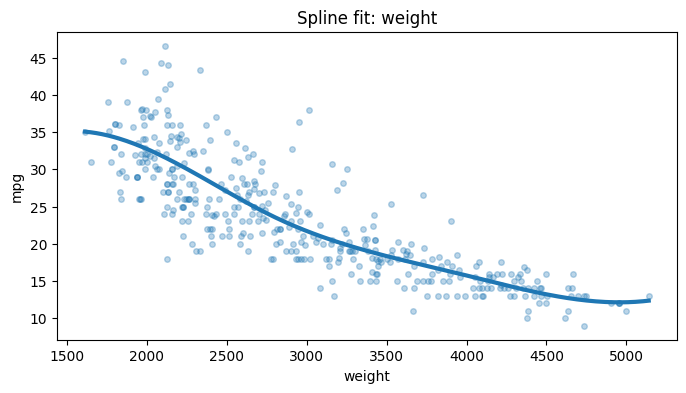

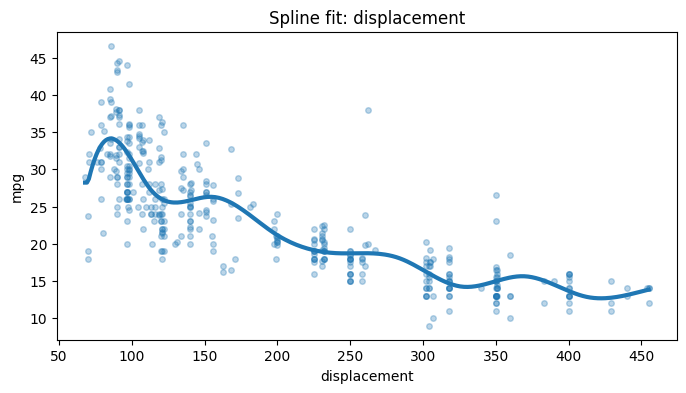

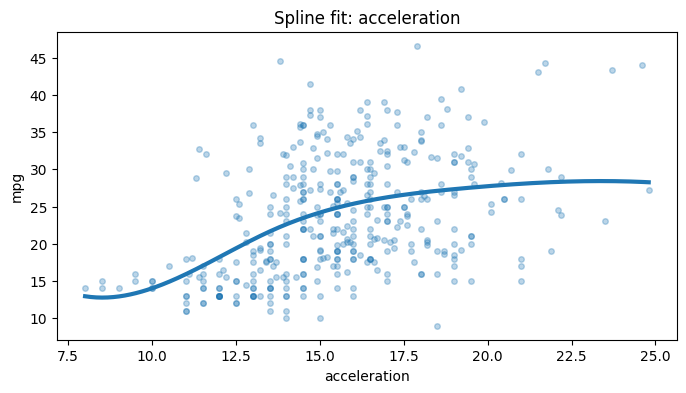

,feature,RMSE,MAE,R2
0,weight,4.027723,3.065008,0.678335
1,displacement,4.416949,3.458962,0.613162
2,acceleration,6.481179,5.369362,0.167101


In [41]:
rows = []

for feature in ["weight","displacement","acceleration"]:
    Xv = auto[[feature]].to_numpy()
    yv = auto["mpg"].to_numpy()

    Xtrv,Xtev,ytrv,ytev = train_test_split(
        Xv,yv,test_size=0.25,random_state=42
    )

    search = GridSearchCV(
        Pipeline([
            ("spline",SplineTransformer(degree=3,include_bias=False)),
            ("ridge",Ridge())
        ]),
        {
            "spline__n_knots":[4,6,8,10,14],
            "ridge__alpha":[0.01,0.1,1,10]
        },
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(Xtrv,ytrv)
    pred = search.predict(Xtev)

    rows.append({
        "feature":feature,
        **metrics(ytev,pred)
    })

    gv = np.linspace(Xv.min(),Xv.max(),300).reshape(-1,1)

    plt.figure(figsize=(8,4))
    plt.scatter(Xv,yv,s=16,alpha=0.3)
    plt.plot(gv,search.predict(gv),linewidth=3)
    plt.xlabel(feature)
    plt.ylabel("mpg")
    plt.title(f"Spline fit: {feature}")
    plt.show()

pd.DataFrame(rows).sort_values("RMSE")

## Exercise 6 — Add Cylinders and Origin

Treat continuous variables with splines and discrete/categorical variables using one-hot encoding.

In [42]:
continuous = ["horsepower","weight","displacement","acceleration","model_year"]
categorical = ["cylinders","origin"]

Xe6 = auto[continuous+categorical]
ye6 = auto["mpg"]

Xtr6,Xte6,ytr6,yte6 = train_test_split(
    Xe6,ye6,test_size=0.25,random_state=42
)

prep = ColumnTransformer([
    (
        "smooth",
        SplineTransformer(n_knots=7,degree=3,include_bias=False),
        continuous
    ),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical
    )
])

model6 = Pipeline([
    ("features",prep),
    ("ridge",Ridge())
])

search6 = GridSearchCV(
    model6,
    {"ridge__alpha":np.logspace(-3,3,15)},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

search6.fit(Xtr6,ytr6)

print(search6.best_params_)
metrics(yte6,search6.predict(Xte6))

{'ridge__alpha': 1.0}


{'RMSE': 2.4587812790672428,
 'MAE': 1.830305251808012,
 'R2': 0.8801262680570909}

## Exercise 7 — Curse of Dimensionality Simulation

We generate

\[
Y=\sin(X_1)+\varepsilon
\]

and add irrelevant dimensions.

The true signal stays one-dimensional, but Euclidean neighborhoods become less useful as irrelevant dimensions accumulate.

In [43]:
def nw_multi_predict(X_train,y_train,X_eval,h):
    preds = []

    for x0 in X_eval:
        diff = X_train-x0
        sq = np.sum(diff**2,axis=1)
        w = np.exp(-0.5*sq/h**2)

        preds.append(
            y_train.mean() if w.sum()<1e-12
            else np.dot(w,y_train)/w.sum()
        )

    return np.asarray(preds)

dim_rows = []

for d in [1,2,4,8]:
    Xd = np.random.uniform(-3,3,size=(700,d))
    yd = np.sin(Xd[:,0]) + np.random.normal(0,0.25,700)

    Xtrd,Xted,ytrd,yted = train_test_split(
        Xd,yd,test_size=0.3,random_state=42
    )

    best_rmse = np.inf
    best_h = None

    for h in [0.25,0.5,0.8,1.2,1.8,2.5]:
        pred = nw_multi_predict(Xtrd,ytrd,Xted,h)
        rmse = mean_squared_error(yted,pred)**0.5

        if rmse < best_rmse:
            best_rmse = rmse
            best_h = h

    dim_rows.append({
        "dimension":d,
        "best_bandwidth":best_h,
        "test_RMSE":best_rmse
    })

dim_results = pd.DataFrame(dim_rows)
dim_results

,dimension,best_bandwidth,test_RMSE
0,1,0.25,0.253157
1,2,0.25,0.259019
2,4,0.80,0.371247
3,8,1.20,0.475540


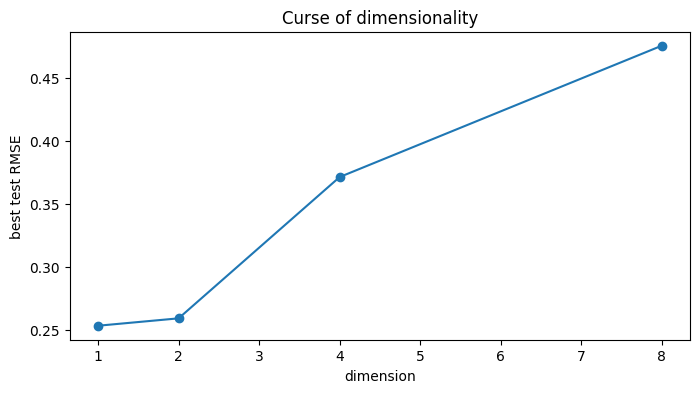

In [44]:
plt.figure(figsize=(8,4))
plt.plot(dim_results["dimension"],dim_results["test_RMSE"],marker="o")
plt.xlabel("dimension")
plt.ylabel("best test RMSE")
plt.title("Curse of dimensionality")
plt.show()

## Exercise 8 — Statistical Smoothers vs ML Models

Do not compare models only on RMSE.

Evaluate:

1. predictive accuracy,
2. interpretability,
3. smoothness,
4. extrapolation behavior.

Tree ensembles may predict extremely well, while splines and additive models often make functional relationships easier to inspect.

In [45]:
comparison.sort_values("RMSE")

,Model,RMSE,MAE,R2
1,Random Forest,2.471832,1.718482,0.878850
3,Additive spline,2.515248,1.826528,0.874557
2,Hist Gradient Boosting,2.561952,1.827195,0.869855
0,Linear full,3.184738,2.408608,0.798891


# 21. Advanced Topic — Effective Degrees of Freedom

Many smoothers can be written

\[
\hat y=Sy.
\]

The smoother matrix \(S\) describes how observed responses are averaged to form fitted values.

A common complexity measure is

\[
df_{\text{eff}}=\operatorname{tr}(S).
\]

For Ridge regression on spline basis \(B\),

\[
S=B(B^\top B+\lambda I)^{-1}B^\top.
\]

Increasing \(\lambda\) decreases effective degrees of freedom.

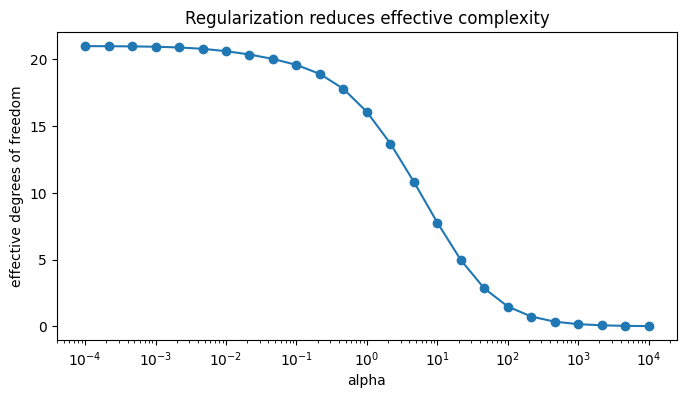

In [46]:
Bdemo = SplineTransformer(
    n_knots=20,
    degree=3,
    include_bias=False
).fit_transform(X)

BtB = Bdemo.T@Bdemo

alphas = np.logspace(-4,4,25)
edf = []

for a in alphas:
    S = Bdemo @ np.linalg.inv(BtB + a*np.eye(BtB.shape[0])) @ Bdemo.T
    edf.append(np.trace(S))

plt.figure(figsize=(8,4))
plt.plot(alphas,edf,marker="o")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("effective degrees of freedom")
plt.title("Regularization reduces effective complexity")
plt.show()

# 22. Residual Diagnostics

Residuals are

\[
e_i=y_i-\hat y_i.
\]

Plotting residuals against fitted values and predictors can reveal:
- omitted nonlinear structure,
- heteroscedasticity,
- outliers,
- missing predictors.

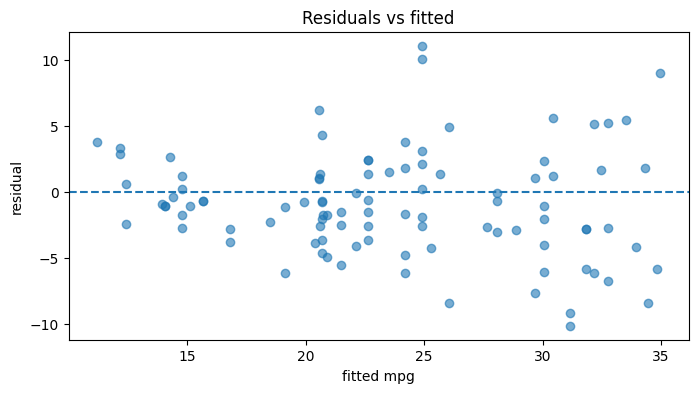

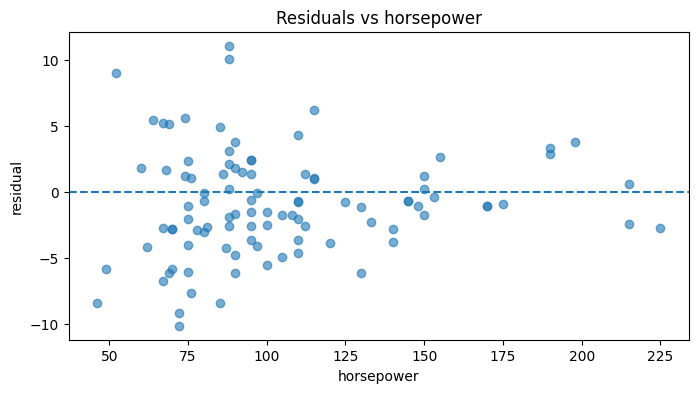

In [47]:
best_pred = spline_search.predict(Xte)
resid = yte-best_pred

plt.figure(figsize=(8,4))
plt.scatter(best_pred,resid,alpha=0.6)
plt.axhline(0,linestyle="--")
plt.xlabel("fitted mpg")
plt.ylabel("residual")
plt.title("Residuals vs fitted")
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(Xte.ravel(),resid,alpha=0.6)
plt.axhline(0,linestyle="--")
plt.xlabel("horsepower")
plt.ylabel("residual")
plt.title("Residuals vs horsepower")
plt.show()

# 23. Computational Complexity

## Nadaraya–Watson

For \(n\) training observations and \(m\) prediction points:

\[
\Theta(mn).
\]

If \(m=n\):

\[
\Theta(n^2).
\]

## Local Polynomial

For small fixed polynomial degree \(p\), naive computation is roughly

\[
O(mnp^2).
\]

## Regression Splines

With \(K\) basis functions, dense least squares is roughly

\[
O(nK^2+K^3)
\]

for fitting and

\[
O(mK)
\]

for prediction.

If \(K\ll n\), spline prediction is much cheaper than instance-based kernel smoothing.

## Efficiency Tips

For large datasets:
- use spline bases,
- use compact-support kernels,
- combine kernels with nearest-neighbor search,
- use approximate nearest neighbors,
- vectorize computations,
- use additive structure,
- use low-rank kernel approximations.

# 24. Final Concept Map

\[
\boxed{
\text{Histogram}
\rightarrow
\text{KDE}
\rightarrow
\text{Kernel Regression}
\rightarrow
\text{Local Polynomial}
\rightarrow
\text{Splines}
\rightarrow
\text{Additive Models}
\rightarrow
\text{Semiparametric Models}
}
\]

The central statistical balancing act is

\[
\boxed{
\text{Flexibility}
\quad\text{vs}\quad
\text{Generalization}
}
\]

controlled through

\[
\boxed{
\text{bandwidth}
+
\text{knots}
+
\text{penalties}
+
\text{cross-validation}
+
\text{structural assumptions}
}
\]

Nonparametric regression is therefore not just “curve fitting.” It is the study of how to recover unknown functional structure while controlling smoothness, variance, dimensionality, and computational cost.